In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import h5py
from matplotlib.colors import LogNorm

In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["figure.figsize"] = [10, 10]
mpl.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 35
mpl.rcParams['image.cmap'] = 'viridis'
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.2
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = False
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 35
mpl.rcParams['ytick.labelsize'] = 35
mpl.rcParams['xtick.major.width'] = 4
mpl.rcParams['ytick.major.width'] = 4
mpl.rcParams['xtick.minor.width'] = 4
mpl.rcParams['ytick.minor.width'] = 4
mpl.rcParams['xtick.major.size'] = 20
mpl.rcParams['ytick.major.size'] = 20
mpl.rcParams['xtick.minor.size'] = 12
mpl.rcParams['ytick.minor.size'] = 12
mpl.rcParams['lines.markeredgecolor'] = 'k'
mpl.rcParams['lines.markeredgewidth'] = 0.8
mpl.rcParams['lines.markersize'] = 50
mpl.rcParams['axes.linewidth'] = 4
mpl.rcParams["pdf.use14corefonts"]= True

from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=plt.cm.viridis(np.linspace(0, 1, 7)))

In [7]:
data_file = '../../testing/testing_new_structure_xraydat.hdf5' #path to saved stacked radial data-should be the only thing you need to change

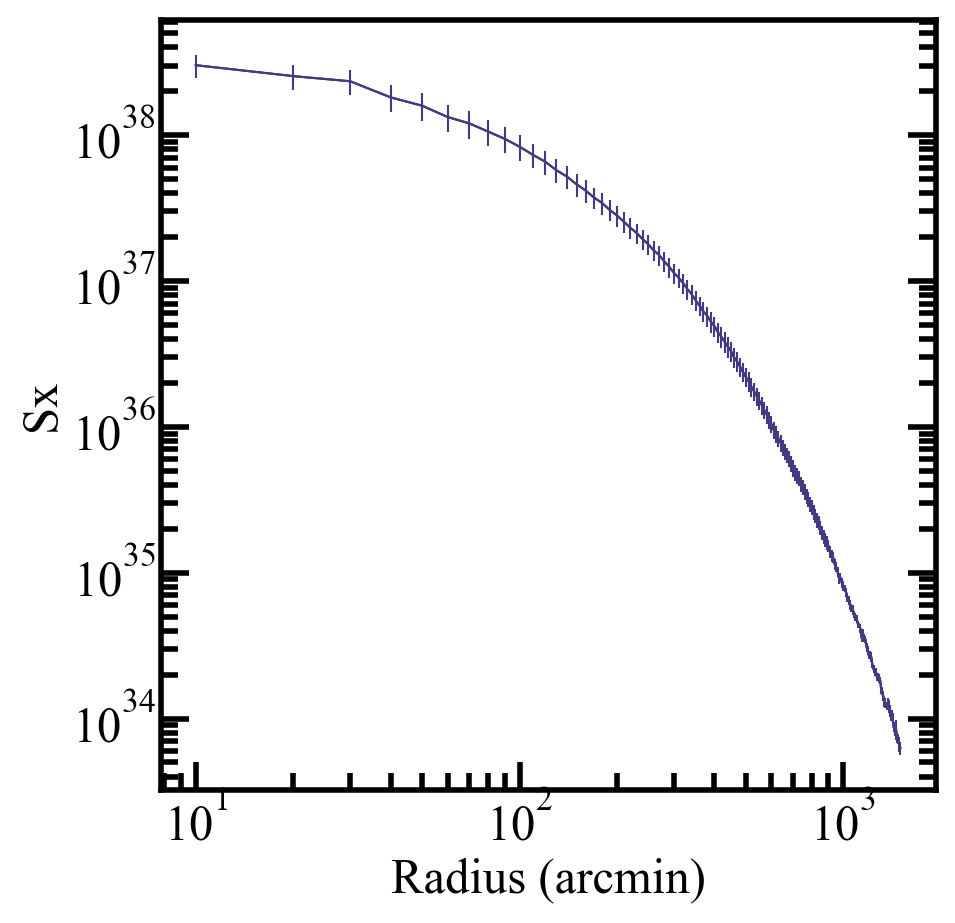

In [9]:
#-------------RADIAL PROFILES-------------#
with h5py.File(data_file, 'r') as f:
    x_a = f['radial_profile/radius'][:]
    y_a = f['radial_profile/Sx'][:]
    err_a = f['radial_profile/error'][:]

plt.plot(x_a[1:],y_a)
plt.errorbar(x_a[1:],y_a, yerr=err_a)
plt.xlabel('Radius (arcmin)')
plt.ylabel('Sx')
plt.yscale('log')
plt.xscale('log')
#plt.savefig('radialprof.png')
plt.show()


In [16]:
#-------------RADIAL PROFILES-------------#
with h5py.File(data_file, 'r') as f:
    y_a = f['image/image_dat'][:]


In [17]:
np.min(y_a)

0.0

Text(0, 0.5, '')

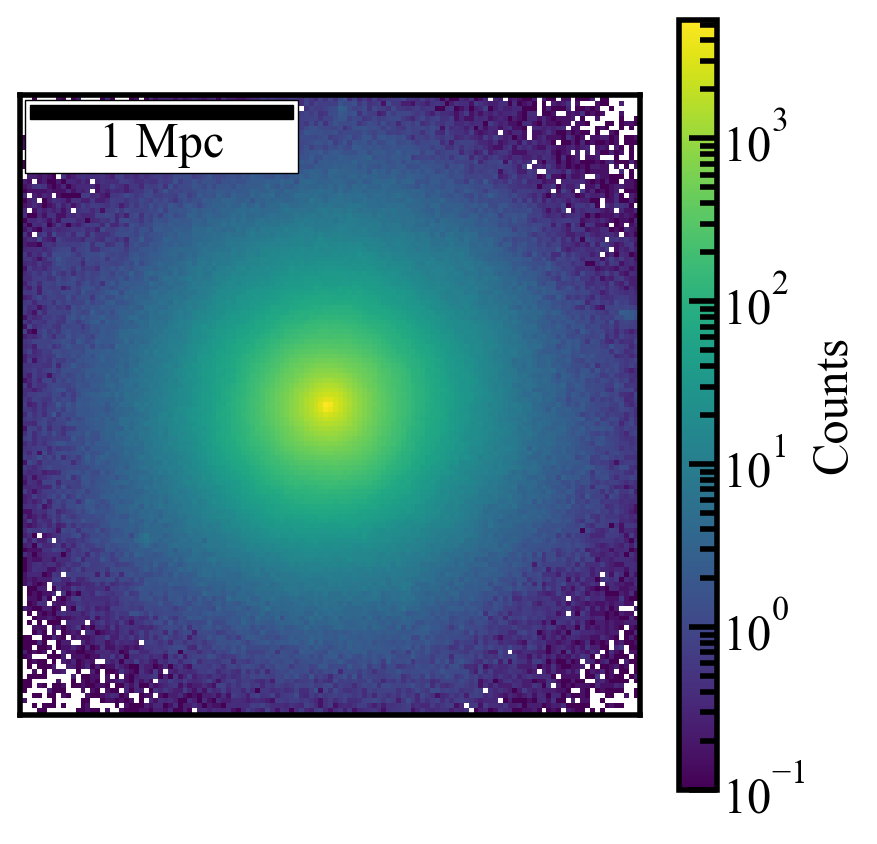

In [18]:
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
fig, ax = plt.subplots()
y_a[y_a == 1e-8] = 1e-1
plt.imshow(y_a, norm=colors.LogNorm(vmin=1e-1, vmax=np.max(y_a)))
plt.colorbar(label='Counts')
plt.xlim(384-384/6,384+384/6)
plt.ylim(384-384/6,384+384/6)

scalebar = AnchoredSizeBar(ax.transData,
                           54.38, '1 Mpc', 'upper left', 
                           pad=0.1,
                           color='black',
                           frameon=True,
                          size_vertical=3)

ax.add_artist(scalebar)
ax.set_xticks([])  # Remove x ticks
ax.set_yticks([])  # Remove y ticks
ax.set_xlabel("")   # Remove x label
ax.set_ylabel("")